Name : Abhinesh Kumar Gangwar

University Roll No. : 2028614

Section : G


Q-15 Consider a dataset containing records related to customer purchasing
behavior. The dataset includes multiple numerical features describing
customer demographics and spending patterns.The program should perform
the following tasks:

i. Read the given dataset into a dataframe.

ii. Perform necessary data preprocessing and feature scaling.

iii. Apply the K-Means Clustering algorithm on the dataset for different
values of K.

iv. Determine the optimal number of clusters using the Elbow Method.

v. Validate the clustering results using the Silhouette Score.

vi. Perform clustering using the optimal value of K and assign cluster labels
to the data points.

vii. Visualize the formed clusters and analyze the clustering results.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [88]:
df=pd.DataFrame(pd.read_csv("customer.csv"))
df.head()

,CustomerID,Age,Annual_Income_k₹,Spending_Score,Online_Purchases,Store_Purchases,Avg_Transaction_Value
0,1,23,15,39,12,8,45
1,2,45,40,81,25,15,120
2,3,34,60,6,5,20,30
3,4,25,25,77,20,10,95
4,5,52,80,40,15,25,110


In [89]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Annual_Income_k₹,0
Spending_Score,0
Online_Purchases,0
Store_Purchases,0
Avg_Transaction_Value,0


In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
df.drop("CustomerID",axis=1,inplace=True)

In [92]:
df=df[(df["Annual_Income_k₹"]>0) & (df["Avg_Transaction_Value"]>0) & (df["Spending_Score"].between(0,100))]

In [93]:
q1=df.quantile(0.25)
q3=df.quantile(0.75)
iqr=q3-q1

In [94]:
df_model=df[~((df<(q1-1.5*iqr)) | (df>(q3+1.5*iqr))).any(axis=1)]
df_model.head()

,Age,Annual_Income_k₹,Spending_Score,Online_Purchases,Store_Purchases,Avg_Transaction_Value
0,23,15,39,12,8,45
1,45,40,81,25,15,120
2,34,60,6,5,20,30
3,25,25,77,20,10,95
4,52,80,40,15,25,110


In [95]:
ss=StandardScaler()
df_scaled=pd.DataFrame(ss.fit_transform(df_model),columns=df_model.columns)
df_scaled.head()

,Age,Annual_Income_k₹,Spending_Score,Online_Purchases,Store_Purchases,Avg_Transaction_Value
0,-1.157561,-1.340760,-0.390353,-0.537122,-0.752814,-0.895028
1,0.596109,-0.347284,0.901021,0.308138,-0.256080,0.859431
2,-0.280726,0.447496,-1.405005,-0.992262,0.098730,-1.245920
3,-0.998136,-0.943370,0.778033,-0.016962,-0.610890,0.274611
4,1.154095,1.242276,-0.359606,-0.342062,0.453540,0.625503


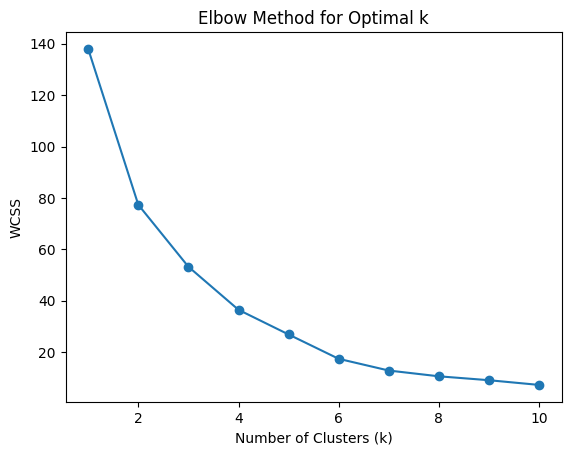

In [96]:
wcss=[]
K=range(1,11)
for k in K:
    kmeans =KMeans(n_clusters=k,n_init=10,random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
plt.figure()
plt.plot(K,wcss,marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

In [97]:
for k in [2,3,4,5,6]:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=km.fit_predict(df_scaled)
    print(f"k={k}, silhouette={silhouette_score(df_scaled,labels):.3f}")

k=2, silhouette=0.360
k=3, silhouette=0.348
k=4, silhouette=0.391
k=5, silhouette=0.400
k=6, silhouette=0.450


In [98]:
kmeans=KMeans(n_clusters=6,random_state=42, n_init=10)
df_model = df_model.copy()
df_model["Cluster"]=kmeans.fit_predict(df_scaled)
df_model.head()

,Age,Annual_Income_k₹,Spending_Score,Online_Purchases,Store_Purchases,Avg_Transaction_Value,Cluster
0,23,15,39,12,8,45,3
1,45,40,81,25,15,120,1
2,34,60,6,5,20,30,5
3,25,25,77,20,10,95,2
4,52,80,40,15,25,110,0


In [99]:
df_model.groupby('Cluster').mean()

,Age,Annual_Income_k₹,Spending_Score,Online_Purchases,Store_Purchases,Avg_Transaction_Value
Cluster,,,,,,
0,50.000000,81.600000,24.400000,10.400000,32.000000,109.000000
1,38.333333,55.333333,68.166667,24.833333,15.000000,130.000000
2,24.833333,22.166667,89.666667,39.666667,5.333333,61.666667
3,22.500000,12.500000,20.500000,6.000000,5.000000,27.500000
4,70.000000,40.000000,60.000000,2.000000,60.000000,70.000000
5,39.666667,61.000000,6.333333,4.333333,25.333333,31.666667


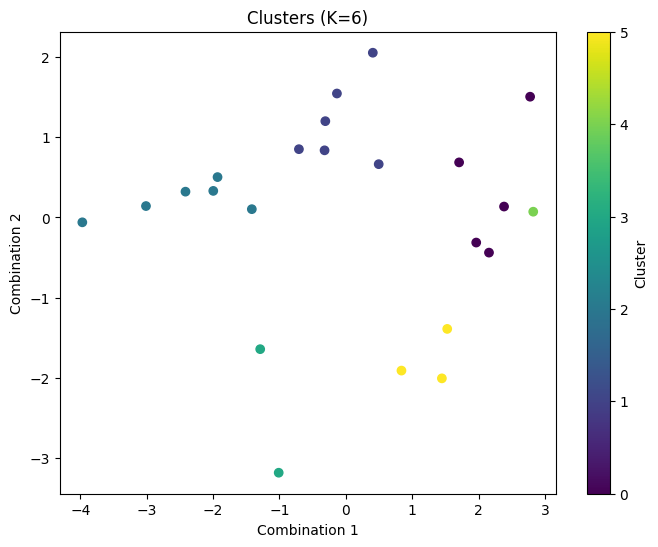

In [104]:
pca=PCA(n_components=2)
df_pca=pca.fit_transform(df_scaled)
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:,0], df_pca[:,1],c=df_model['Cluster'])
plt.title("Clusters (K=6)")
plt.xlabel("Combination 1")
plt.ylabel("Combination 2")
plt.colorbar(label='Cluster')
plt.show()

In [107]:
df_model.groupby('Cluster').mean()

,Age,Annual_Income_k₹,Spending_Score,Online_Purchases,Store_Purchases,Avg_Transaction_Value
Cluster,,,,,,
0,50.000000,81.600000,24.400000,10.400000,32.000000,109.000000
1,38.333333,55.333333,68.166667,24.833333,15.000000,130.000000
2,24.833333,22.166667,89.666667,39.666667,5.333333,61.666667
3,22.500000,12.500000,20.500000,6.000000,5.000000,27.500000
4,70.000000,40.000000,60.000000,2.000000,60.000000,70.000000
5,39.666667,61.000000,6.333333,4.333333,25.333333,31.666667


# Interpretation for different clusters
---

| Cluster | Interpretation                                      |
|---------|----------------------------------------------------|
| **0**   | Older, high-income, cautious in-store spenders.   |
| **1**   | Active online shoppers with moderate income.      |
| **2**   | Young, low-income but high online spenders.       |
| **3**   | Young, low-income, low-engagement customers.      |
| **4**   | Old, loyal offline shoppers with moderate income. |
| **5**   | Middle-aged, low spending, possibly inactive.     |